In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
import os 
print(os.getcwd())

d:\BookRecommendation\notebook


In [3]:
import pandas as pd

ratings_df    = pd.read_csv(r'd:\BookRecommendation\data\processed\clean_book_ratings.csv')
user_features = pd.read_csv(r'd:\BookRecommendation\data\processed\user_features.csv')
book_features = pd.read_csv(r'd:\BookRecommendation\data\processed\book_features.csv')
user_clusters = pd.read_csv(r'd:\BookRecommendation\data\processed\user_clusters.csv')
book_clusters = pd.read_csv(r'd:\BookRecommendation\data\processed\book_clusters.csv')
cf_scores_df  = pd.read_csv(r'd:\BookRecommendation\data\processed\cf_scores.csv')

print("Ratings columns:      ", ratings_df.columns.tolist())
print("User features columns:", user_features.columns.tolist())
print("Book features columns:", book_features.columns.tolist())
print("User clusters columns:", user_clusters.columns.tolist())
print("Book clusters columns:", book_clusters.columns.tolist())
print("CF scores columns:    ", cf_scores_df.columns.tolist())

Ratings columns:       ['index', 'ISBN', 'Book_Title', 'Book_Author', 'Year_Of_Publication', 'Publisher', 'User_ID', 'Book_Rating', 'Age_Group', 'Country']
User features columns: ['User_ID', 'user_avg_rating', 'user_rating_count', 'user_rating_std', 'Age_Group', 'Country', 'favourite_author', 'old_books_ratio', 'recent_books_ratio', 'genre_diversity']
Book features columns: ['ISBN', 'Book_avg_rating', 'Book_rating_count', 'Book_rating_std', 'Year_Of_Publication', 'Publisher', 'Genre', 'Title_Author_combined', 'Genre_grouped']
User clusters columns: ['User_ID', 'user_avg_rating', 'user_rating_count', 'user_rating_std', 'Age_Group', 'Country', 'favourite_author', 'old_books_ratio', 'recent_books_ratio', 'genre_diversity', 'user_cluster']
Book clusters columns: ['ISBN', 'Book_avg_rating', 'Book_rating_count', 'Book_rating_std', 'Year_Of_Publication', 'Publisher', 'Genre', 'Title_Author_combined', 'Genre_grouped', 'book_cluster']
CF scores columns:     ['User_ID', 'ISBN', 'cf_predicted_sco

In [4]:
xgb_df = ratings_df[ratings_df['Book_Rating']>0][
    ['User_ID','ISBN','Book_Author','Book_Rating']].copy().reset_index(drop=True)


In [5]:
user_cols = ['User_ID', 'user_avg_rating', 'user_rating_count', 'user_rating_std', 'Age_Group', 'Country', 'favourite_author', 'old_books_ratio', 'recent_books_ratio', 'genre_diversity']

xgb_df = xgb_df.merge(user_features[user_cols], on='User_ID', how='left')

In [6]:
xgb_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 63345 entries, 0 to 63344
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             63345 non-null  int64  
 1   ISBN                63345 non-null  str    
 2   Book_Author         63345 non-null  str    
 3   Book_Rating         63345 non-null  int64  
 4   user_avg_rating     63345 non-null  float64
 5   user_rating_count   63345 non-null  int64  
 6   user_rating_std     63345 non-null  float64
 7   Age_Group           63345 non-null  str    
 8   Country             63345 non-null  str    
 9   favourite_author    63345 non-null  str    
 10  old_books_ratio     63345 non-null  float64
 11  recent_books_ratio  63345 non-null  float64
 12  genre_diversity     63345 non-null  int64  
dtypes: float64(4), int64(4), str(5)
memory usage: 9.2 MB


In [7]:
xgb_df = xgb_df.merge(user_clusters[['User_ID','user_cluster']]
                      ,on='User_ID',
                      how='left')

In [8]:
book_cols = ['ISBN', 'Book_avg_rating', 'Book_rating_count',
             'Book_rating_std', 'Year_Of_Publication', 'Genre_grouped']


xgb_df = xgb_df.merge(book_features[book_cols] , on='ISBN' , how='left')

In [9]:
xgb_df = xgb_df.merge(book_clusters[['ISBN','book_cluster']] , on='ISBN' , how='left')


In [10]:
xgb_df = xgb_df.merge(cf_scores_df , on=['User_ID','ISBN'] , how='left')

In [11]:
print("xgb_df types:")
print(xgb_df[['User_ID', 'ISBN']].dtypes)

print("\ncf_scores_df types:")
print(cf_scores_df[['User_ID', 'ISBN']].dtypes)

xgb_df types:
User_ID    int64
ISBN         str
dtype: object

cf_scores_df types:
User_ID    int64
ISBN         str
dtype: object


In [12]:
# !pip install tqdm

In [13]:
import joblib
from tqdm import tqdm
tqdm.pandas()

# Load SVD model if not already loaded
svd_model = joblib.load(r'd:\BookRecommendation\ml_models\cf_svd_model.pkl')

# Predict CF score for each explicit rating pair
xgb_df['cf_predicted_score'] = xgb_df.progress_apply(
    lambda row: svd_model.predict(
        uid=row['User_ID'],
        iid=row['ISBN']
    ).est, axis=1
)

print(xgb_df['cf_predicted_score'].describe())

100%|██████████| 63345/63345 [00:01<00:00, 52977.39it/s]

count    63345.000000
mean         7.842065
std          1.017684
min          1.381996
25%          7.281717
50%          7.915875
75%          8.526259
max         10.000000
Name: cf_predicted_score, dtype: float64


In [14]:
xgb_df.columns

Index(['User_ID', 'ISBN', 'Book_Author', 'Book_Rating', 'user_avg_rating',
       'user_rating_count', 'user_rating_std', 'Age_Group', 'Country',
       'favourite_author', 'old_books_ratio', 'recent_books_ratio',
       'genre_diversity', 'user_cluster', 'Book_avg_rating',
       'Book_rating_count', 'Book_rating_std', 'Year_Of_Publication',
       'Genre_grouped', 'book_cluster', 'cf_predicted_score'],
      dtype='str')

In [15]:
# xgb_df.drop(columns=['cf_predicted_score_y'] , inplace=True)

In [16]:
# Genre match — does user's favourite author match book author?
xgb_df['author_match'] = (
    xgb_df['favourite_author'] == xgb_df['Book_Author']
).astype(int)

# Popularity signal
median_count = book_features['Book_rating_count'].median()
xgb_df['is_popular'] = (
    xgb_df['Book_rating_count'] > median_count
).astype(int)

# Implicit interaction signal
implicit = ratings_df[ratings_df['Book_Rating'] == 0][
    ['User_ID', 'ISBN']
].copy()
implicit['interacted'] = 1

xgb_df = xgb_df.merge(implicit, on=['User_ID', 'ISBN'], how='left')
xgb_df['interacted'] = xgb_df['interacted'].fillna(0).astype(int)

print(f"After interaction features: {xgb_df.shape}")

After interaction features: (63345, 24)


In [17]:
xgb_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 63345 entries, 0 to 63344
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   User_ID              63345 non-null  int64  
 1   ISBN                 63345 non-null  str    
 2   Book_Author          63345 non-null  str    
 3   Book_Rating          63345 non-null  int64  
 4   user_avg_rating      63345 non-null  float64
 5   user_rating_count    63345 non-null  int64  
 6   user_rating_std      63345 non-null  float64
 7   Age_Group            63345 non-null  str    
 8   Country              63345 non-null  str    
 9   favourite_author     63345 non-null  str    
 10  old_books_ratio      63345 non-null  float64
 11  recent_books_ratio   63345 non-null  float64
 12  genre_diversity      63345 non-null  int64  
 13  user_cluster         63345 non-null  int64  
 14  Book_avg_rating      63345 non-null  float64
 15  Book_rating_count    63345 non-null  int64  
 1

In [18]:
xgb_df.rename(columns={'cf_predicted_score_x':'cf_predicted_score'} ,inplace=True)

In [19]:
xgb_df.drop(columns=['ISBN', 'Book_Author', 
                      'favourite_author', 'Country'], inplace=True)

In [20]:
xgb_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 63345 entries, 0 to 63344
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   User_ID              63345 non-null  int64  
 1   Book_Rating          63345 non-null  int64  
 2   user_avg_rating      63345 non-null  float64
 3   user_rating_count    63345 non-null  int64  
 4   user_rating_std      63345 non-null  float64
 5   Age_Group            63345 non-null  str    
 6   old_books_ratio      63345 non-null  float64
 7   recent_books_ratio   63345 non-null  float64
 8   genre_diversity      63345 non-null  int64  
 9   user_cluster         63345 non-null  int64  
 10  Book_avg_rating      63345 non-null  float64
 11  Book_rating_count    63345 non-null  int64  
 12  Book_rating_std      63345 non-null  float64
 13  Year_Of_Publication  63345 non-null  int64  
 14  Genre_grouped        63345 non-null  str    
 15  book_cluster         63345 non-null  int64  
 1

In [21]:
xgb_df

,User_ID,Book_Rating,user_avg_rating,user_rating_count,user_rating_std,Age_Group,old_books_ratio,recent_books_ratio,genre_diversity,user_cluster,Book_avg_rating,Book_rating_count,Book_rating_std,Year_Of_Publication,Genre_grouped,book_cluster,cf_predicted_score,author_match,is_popular,interacted
0,11676,9,4.952328,1804,3.998468,Unknown,0.583149,0.416851,67,3,3.954545,22,3.954545,1991,Fiction,4,9.068546,0,1,0
1,29526,9,6.142857,63,4.603145,Adult,0.396825,0.603175,13,0,3.954545,22,3.954545,1991,Fiction,4,9.715675,0,1,0
2,46398,9,3.329670,182,3.899440,Middle_Age,0.730769,0.269231,32,3,3.954545,22,3.954545,1991,Fiction,4,7.650869,0,1,0
3,49635,9,2.062500,16,3.714274,Unknown,0.937500,0.062500,8,2,3.954545,22,3.954545,1991,Fiction,4,8.553941,1,1,0
4,67958,10,9.333333,3,1.154701,Middle_Age,1.000000,0.000000,2,2,3.954545,22,3.954545,1991,Fiction,4,8.983770,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63340,243360,6,4.625000,32,3.580863,Unknown,0.875000,0.125000,16,2,3.000000,2,3.000000,1999,Romance,4,7.120396,1,0,0
63341,239594,7,4.843750,64,4.186974,Adult,0.593750,0.406250,13,2,7.000000,1,7.000000,1997,Romance,3,8.150458,0,0,0
63342,240567,6,6.164557,79,3.314422,Adult,0.556962,0.443038,19,3,6.000000,1,6.000000,2001,Thriller_Mystery,3,7.034504,0,0,0
63343,244685,9,8.641026,39,1.158201,Unknown,0.615385,0.384615,13,2,9.000000,1,9.000000,1992,Thriller_Mystery,3,8.938959,0,0,0


In [22]:
xgb_df['Age_Group'].nunique()

6

In [23]:
categorical_feature = ['Age_Group','Genre_grouped']
numeric_features = [col for col in xgb_df.columns 
                   if col not in categorical_feature + ['Book_Rating', 
                                                          'User_ID']]


In [24]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


In [25]:
ohe_xgb = OneHotEncoder(drop='first',sparse_output=False)

Preprocessing = ColumnTransformer([
    ('OneHotEncoding' , ohe_xgb , categorical_feature),
    ('numeric', 'passthrough', numeric_features)
])

In [26]:
final_xgb_df = xgb_df.copy()

In [27]:
xgb_df = Preprocessing.fit_transform(xgb_df)

In [28]:
xgb_df

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [29]:
xgb_categorical_feature_name = Preprocessing.named_transformers_['OneHotEncoding'].get_feature_names_out(categorical_feature)
numeric_feature_names = numeric_features

all_feature = list(xgb_categorical_feature_name) + list(numeric_feature_names)

In [30]:
xgb_df = pd.DataFrame(xgb_df,columns=all_feature)

In [31]:
xgb_df

,Age_Group_Middle_Age,Age_Group_Senior,Age_Group_Teen,Age_Group_Unknown,Age_Group_Young_Adult,Genre_grouped_Children,Genre_grouped_Drama_Humor,Genre_grouped_Fiction,Genre_grouped_Historical,Genre_grouped_Horror,...,user_cluster,Book_avg_rating,Book_rating_count,Book_rating_std,Year_Of_Publication,book_cluster,cf_predicted_score,author_match,is_popular,interacted
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,3.0,3.954545,22.0,3.954545,1991.0,4.0,9.068546,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,3.954545,22.0,3.954545,1991.0,4.0,9.715675,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,3.0,3.954545,22.0,3.954545,1991.0,4.0,7.650869,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,2.0,3.954545,22.0,3.954545,1991.0,4.0,8.553941,1.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,2.0,3.954545,22.0,3.954545,1991.0,4.0,8.983770,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63340,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,3.000000,2.0,3.000000,1999.0,4.0,7.120396,1.0,0.0,0.0
63341,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,7.000000,1.0,7.000000,1997.0,3.0,8.150458,0.0,0.0,0.0
63342,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,6.000000,1.0,6.000000,2001.0,3.0,7.034504,0.0,0.0,0.0
63343,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,9.000000,1.0,9.000000,1992.0,3.0,8.938959,0.0,0.0,0.0


In [32]:
xgb_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 63345 entries, 0 to 63344
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age_Group_Middle_Age            63345 non-null  float64
 1   Age_Group_Senior                63345 non-null  float64
 2   Age_Group_Teen                  63345 non-null  float64
 3   Age_Group_Unknown               63345 non-null  float64
 4   Age_Group_Young_Adult           63345 non-null  float64
 5   Genre_grouped_Children          63345 non-null  float64
 6   Genre_grouped_Drama_Humor       63345 non-null  float64
 7   Genre_grouped_Fiction           63345 non-null  float64
 8   Genre_grouped_Historical        63345 non-null  float64
 9   Genre_grouped_Horror            63345 non-null  float64
 10  Genre_grouped_Non_Fiction       63345 non-null  float64
 11  Genre_grouped_Other             63345 non-null  float64
 12  Genre_grouped_Religious         63345 non-n

In [34]:
X = xgb_df
y = final_xgb_df['Book_Rating']


In [36]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (50676, 35)
X_test shape:  (12669, 35)
y_train shape: (50676,)
y_test shape:  (12669,)


In [38]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [40]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV



In [41]:
param_grid = {
    'n_estimators'    : [100, 200, 300],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'max_depth'       : [4, 6, 8],
    'subsample'       : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

In [42]:
xgb_model = XGBRegressor(random_state=42, n_jobs=-1)

In [43]:
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=20,          # try only 20 random combinations
    cv=3,               # 3 fold cross validation
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [44]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies

In [45]:
print(f"Best parameters: {random_search.best_params_}")
print(f"Best score: {np.sqrt(-random_search.best_score_):.4f}")

Best parameters: {'subsample': 0.9, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best score: 1.0823


In [46]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Train with best parameters
xgb_final = XGBRegressor(
    subsample        = 0.9,
    n_estimators     = 100,
    max_depth        = 6,
    learning_rate    = 0.1,
    colsample_bytree = 0.9,
    random_state     = 42,
    n_jobs           = -1
)

xgb_final.fit(X_train, y_train)

# Evaluate
y_pred = xgb_final.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

RMSE : 0.7818
MAE  : 0.5938
R²   : 0.8066


In [47]:
# one more try 
xgb_sec = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train
xgb_sec.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

[0]	validation_0-rmse:1.71257
[50]	validation_0-rmse:0.85336
[100]	validation_0-rmse:0.80375
[150]	validation_0-rmse:0.79187
[199]	validation_0-rmse:0.78498


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [48]:
y_pred = xgb_sec.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

RMSE : 0.7850
MAE  : 0.5962
R²   : 0.8050


                      feature  importance
31         cf_predicted_score    0.659905
33                 is_popular    0.030707
21            user_rating_std    0.021995
20          user_rating_count    0.020668
24            genre_diversity    0.015932
19            user_avg_rating    0.015806
25               user_cluster    0.014813
26            Book_avg_rating    0.014228
27          Book_rating_count    0.013802
28            Book_rating_std    0.013660
12    Genre_grouped_Religious    0.012537
6   Genre_grouped_Drama_Humor    0.011754
32               author_match    0.011041
2              Age_Group_Teen    0.011020
30               book_cluster    0.010893


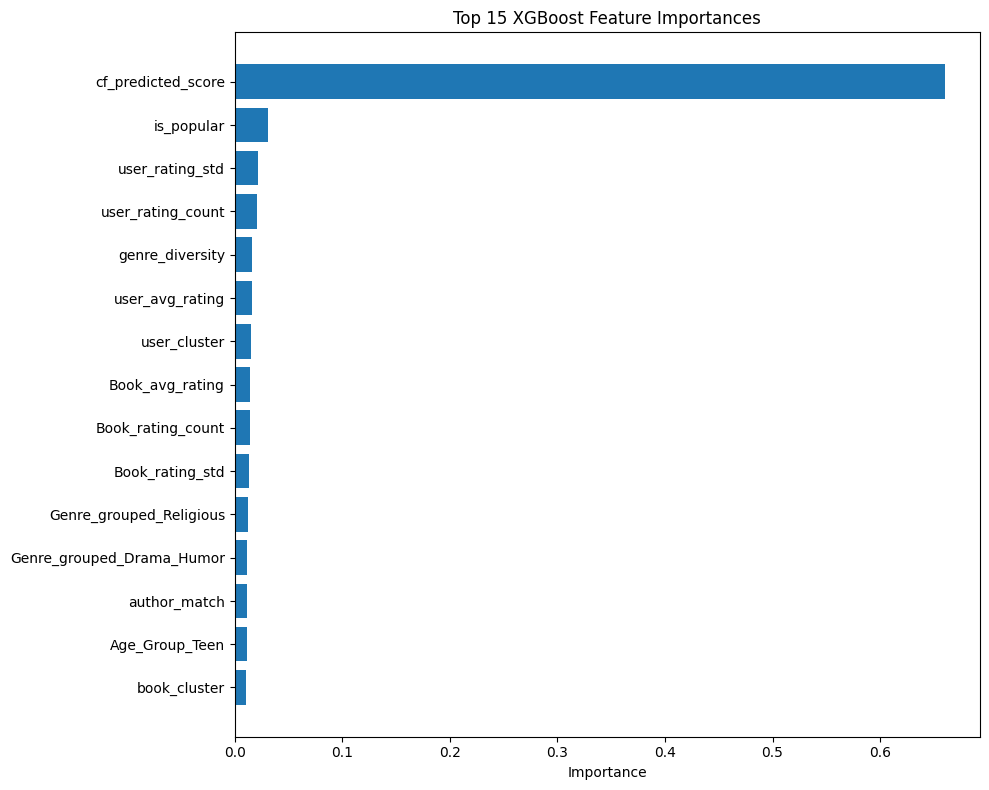

In [49]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance
importance_df = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': xgb_final.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.head(15))

# Plot top 15 features
plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'][:15][::-1],
         importance_df['importance'][:15][::-1])
plt.xlabel('Importance')
plt.title('Top 15 XGBoost Feature Importances')
plt.tight_layout()
plt.show()

In [ ]:
# Stage 1 → Clustering
#           Users: K=4, Silhouette=0.33
#           Books: K=5, Silhouette=0.34

# Stage 2 → Collaborative Filtering
#           SVD: RMSE=1.57, MAE=1.21

# Stage 3 → XGBoost
#           RMSE=0.78, MAE=0.59, R²=0.80
#           50% improvement over CF alone!

In [50]:
import joblib

# Save XGBoost model
joblib.dump(xgb_final, r'd:\BookRecommendation\ml_models\xgb_model.pkl')

# Save preprocessor
joblib.dump(Preprocessing, r'd:\BookRecommendation\ml_models\preprocessor.pkl')

print("XGBoost model and preprocessor saved!")

XGBoost model and preprocessor saved!
